In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [29]:
df = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [30]:
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据描述统计:")
print(df.describe())

数据形状: (1510, 8)

前5行数据:
   id  Depth  Temperature  Salinity  Oxygen      pH  DO_mgL  QualityLevel
0   1   0.00      23.8058   34.6166   212.9  7.9316  6.8128             3
1   2  11.62      23.8044   34.6166   212.3  8.0877  6.7936             3
2   3  22.05      23.8117   34.6166   212.5  8.0876  6.8000             3
3   4  31.59      23.8034   34.6166   212.2  8.0890  6.7904             3
4   5  50.06      23.4602   34.6166   211.0  8.0798  6.7520             3

数据描述统计:
                id        Depth  Temperature     Salinity       Oxygen  \
count  1510.000000  1510.000000  1510.000000  1510.000000  1510.000000   
mean    755.500000   633.711072    14.843679    36.329249   164.949477   
std     436.043767   910.740729     8.632151    16.172397    50.591333   
min       1.000000     0.000000     1.550000    33.513600    57.100000   
25%     378.250000    98.599750     5.987450    34.519550   117.325000   
50%     755.500000   299.945000    17.390400    34.616600   190.900000   
75%  

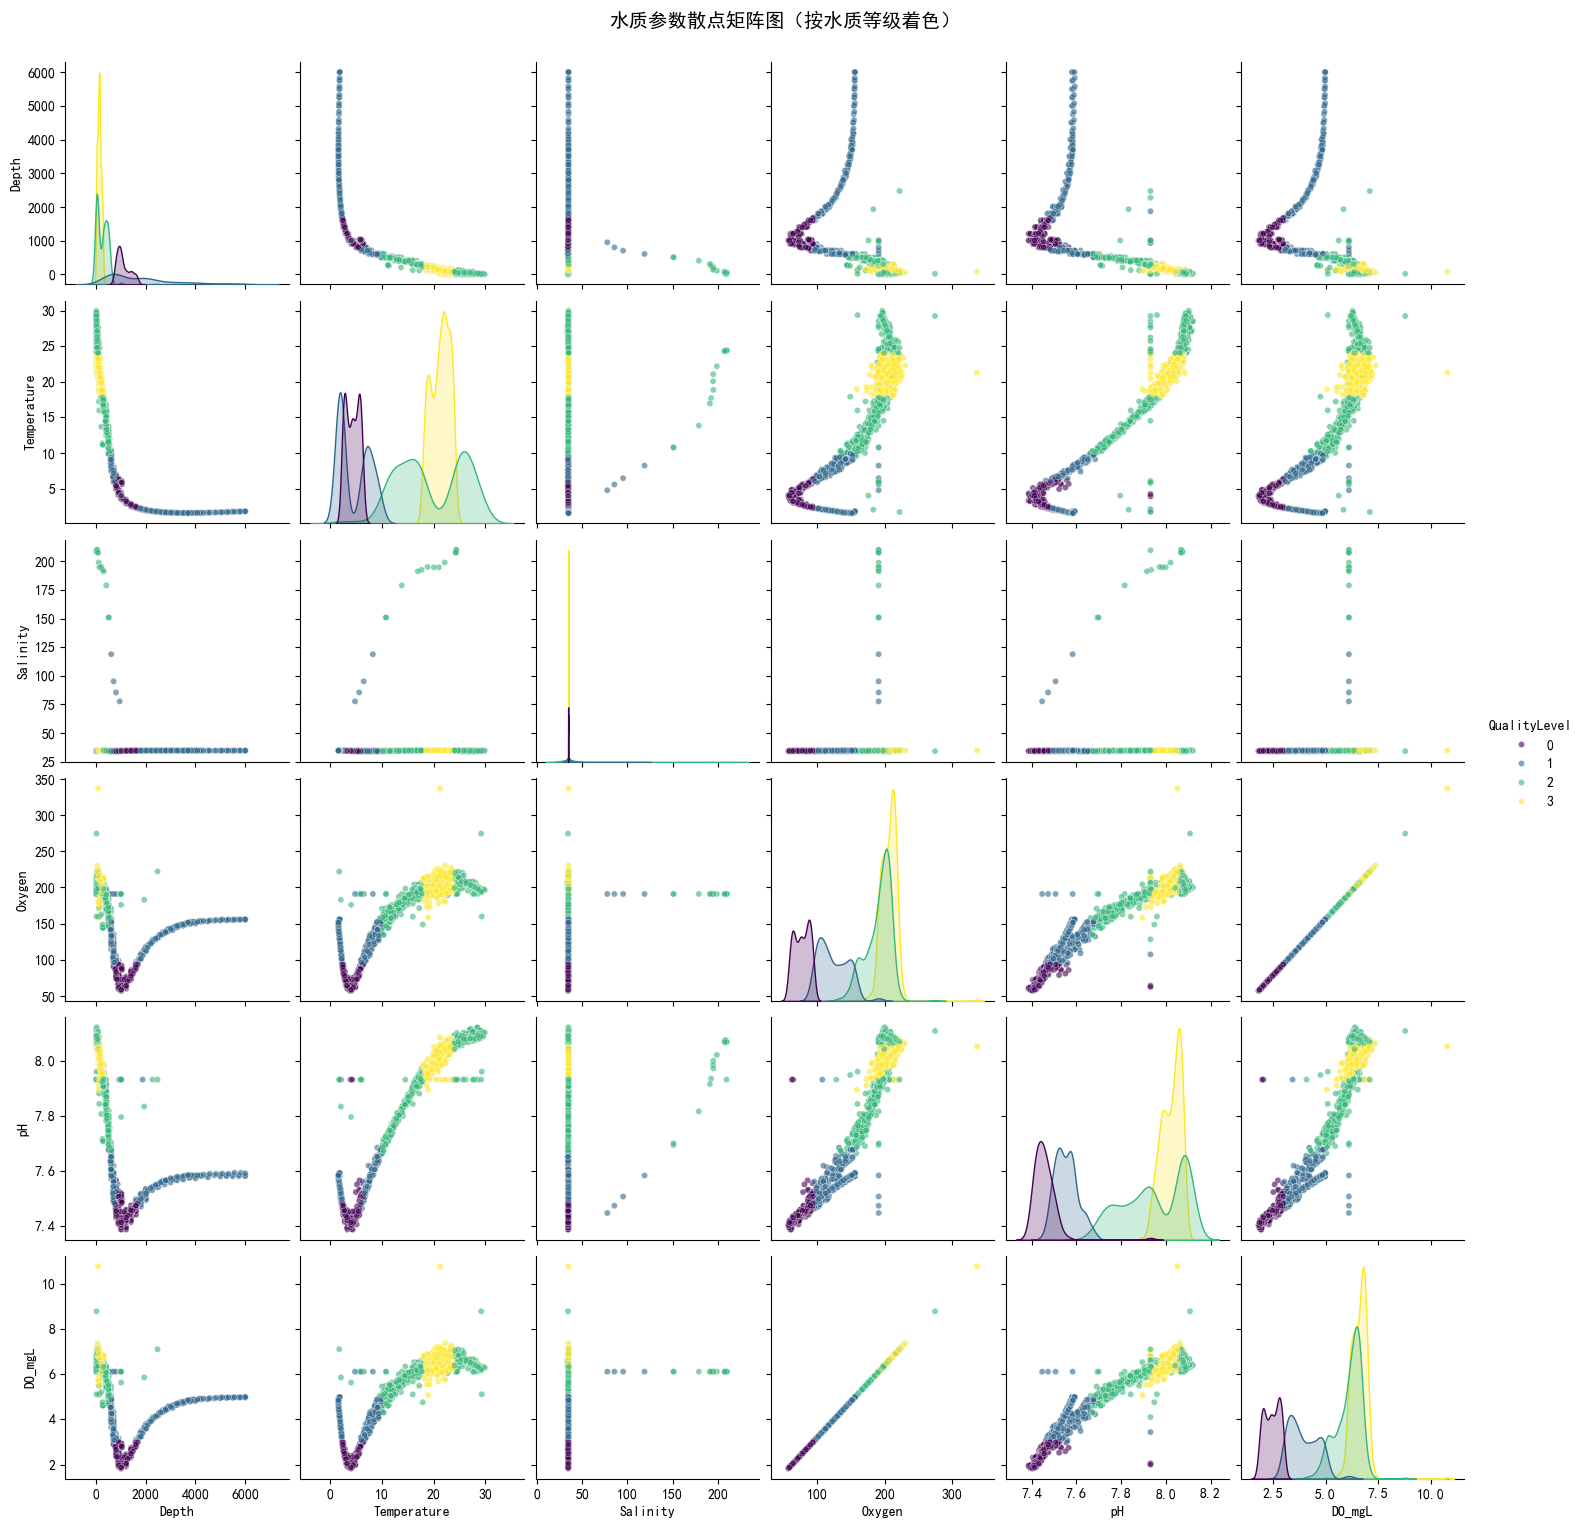

In [31]:
features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH','DO_mgL']
sns.pairplot(df[features + ['QualityLevel']], 
                 diag_kind='kde',  # 对角线用核密度估计
                 hue='QualityLevel',  # 按水质等级着色
                 palette='viridis',
                 plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('水质参数散点矩阵图（按水质等级着色）', y=1.02, fontsize=14)
plt.savefig('散点矩阵图.png', dpi=300, bbox_inches='tight')
plt.show()

各特征与水质等级的Spearman相关系数:
             correlation        p_value
DO_mgL          0.851909   0.000000e+00
Oxygen          0.851909   0.000000e+00
pH              0.781349  4.534643e-311
Depth          -0.750260  2.771965e-273
Temperature     0.732366  5.602661e-254
Salinity        0.563340  3.512123e-127


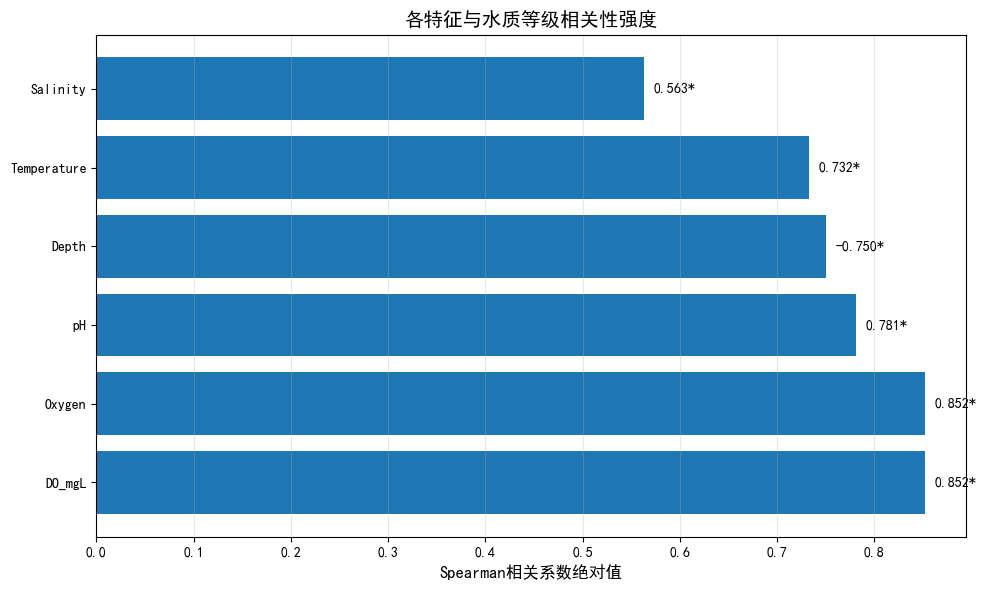

In [32]:
spearman_corr = {}
for feature in features:
    corr, p_value = stats.spearmanr(df[feature], df['QualityLevel'])
    spearman_corr[feature] = {'correlation': corr, 'p_value': p_value}

# 转换为DataFrame
corr_df = pd.DataFrame(spearman_corr).T
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)  # 按绝对值排序

print("各特征与水质等级的Spearman相关系数:")
print(corr_df)

# 可视化
plt.figure(figsize=(10, 6))
bars = plt.barh(corr_df.index, corr_df['correlation'].abs())
plt.xlabel('Spearman相关系数绝对值', fontsize=12)
plt.title('各特征与水质等级相关性强度', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# 添加数值标签
for i, (bar, (idx, row)) in enumerate(zip(bars, corr_df.iterrows())):
    corr_value = row['correlation']
    p_value = row['p_value']
    significance = '*' if p_value < 0.001 else '' if p_value < 0.01 else '' if p_value < 0.05 else ''
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{corr_value:.3f}{significance}', 
             va='center', ha='left')

plt.tight_layout()
plt.savefig('特征与目标相关性.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
print("数据基本信息:")
print(f"样本数: {df.shape[0]}")
print(f"特征数: {df.shape[1] - 1}")  # 减去目标列
print(f"水质等级分布:\n{df['QualityLevel'].value_counts().sort_index()}")

# 1. 划分训练集和测试集（重要！）
X = df[['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH','DO_mgL']]
y = df['QualityLevel']

# 使用分层抽样，确保每个水质等级在训练集和测试集中的比例相同
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y,  # 关键参数！
    shuffle=True
)

print(f"\n数据划分结果:")
print(f"训练集: {X_train.shape[0]} 个样本")
print(f"测试集: {X_test.shape[0]} 个样本")
print(f"训练集类别分布:\n{y_train.value_counts().sort_index()}")
print(f"测试集类别分布:\n{y_test.value_counts().sort_index()}")

数据基本信息:
样本数: 1510
特征数: 7
水质等级分布:
QualityLevel
0    234
1    290
2    488
3    498
Name: count, dtype: int64

数据划分结果:
训练集: 1208 个样本
测试集: 302 个样本
训练集类别分布:
QualityLevel
0    187
1    232
2    390
3    399
Name: count, dtype: int64
测试集类别分布:
QualityLevel
0    47
1    58
2    98
3    99
Name: count, dtype: int64


特征与目标的互信息评分（越高越重要）:
       feature  mutual_info
1  Temperature     1.252325
4           pH     1.016706
0        Depth     0.994518
3       Oxygen     0.948603
5       DO_mgL     0.939120
2     Salinity     0.520050


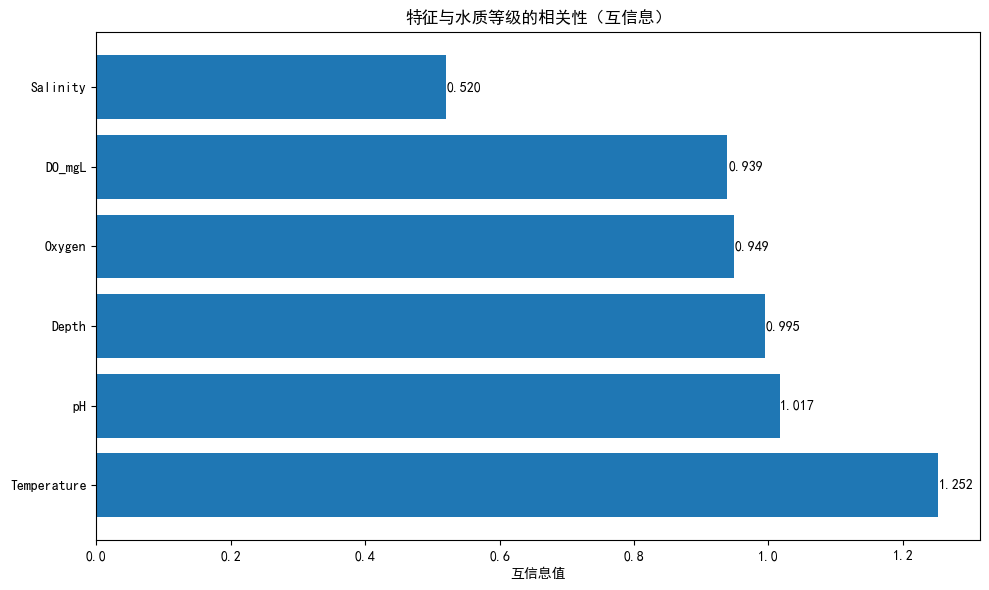

In [34]:
from sklearn.feature_selection import mutual_info_classif

# 计算互信息（可以捕捉非线性关系）
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print("特征与目标的互信息评分（越高越重要）:")
print(mi_df)

# 可视化
plt.figure(figsize=(10, 6))
bars = plt.barh(mi_df['feature'], mi_df['mutual_info'])
plt.xlabel('互信息值')
plt.title('特征与水质等级的相关性（互信息）')
# 为条形图添加数值标签
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center')
plt.tight_layout()
plt.show()

特征相关性矩阵:
             Depth  Temperature  Salinity  Oxygen     pH  DO_mgL
Depth        1.000       -0.741    -0.047  -0.504 -0.636  -0.504
Temperature -0.741        1.000     0.056   0.877  0.960   0.877
Salinity    -0.047        0.056     1.000   0.059  0.050   0.059
Oxygen      -0.504        0.877     0.059   1.000  0.954   1.000
pH          -0.636        0.960     0.050   0.954  1.000   0.954
DO_mgL      -0.504        0.877     0.059   1.000  0.954   1.000


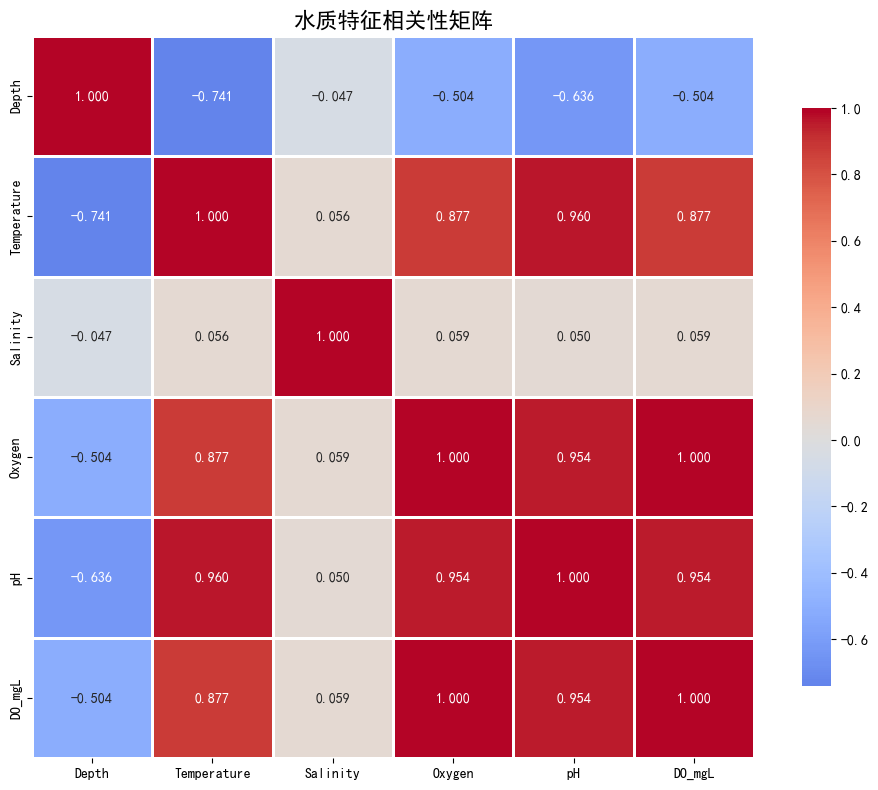


基于相关系数的明确分组:


# 从分析结果可以看到:
# 1. Oxygen和DO_mgL完全相关(r=1.0) - 必须分组
# 2. Temperature和pH高度相关(r=0.96) - 应该分组
# 3. Depth和Salinity相关性很低(r=-0.05) - 不应该分组


第一组（溶解氧组）: ['Oxygen', 'DO_mgL']
  Oxygen-DO_mgL: 1.000 (完全相关!)

第二组（温度-pH组）: ['Temperature', 'pH']
  Temperature-pH: 0.960 (高度相关)

独立特征（不进行PCA）: ['Depth', 'Salinity']
  Depth-Salinity: -0.047 (低相关,保持独立)

最终特征集构成:
  PCA特征: PC1_oxygen (来自['Oxygen', 'DO_mgL']), PC1_temp_pH (来自['Temperature', 'pH'])
  原始特征: ['Depth', 'Salinity']
  总计: 2个PCA特征 + 2个原始特征 = 4个特征


In [35]:
features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH','DO_mgL']

# 计算相关性矩阵
corr_matrix = X_train[features].corr(method='pearson')

print("特征相关性矩阵:")
print(corr_matrix.round(3))

# 可视化相关性
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('水质特征相关性矩阵', fontsize=16)
plt.tight_layout()
plt.show()

"# 明确分组 - 基于实际相关性分析结果\n",
print("\n基于相关系数的明确分组:")
print("="*60)
print("\n")
print("# 从分析结果可以看到:")
print("# 1. Oxygen和DO_mgL完全相关(r=1.0) - 必须分组")
print("# 2. Temperature和pH高度相关(r=0.96) - 应该分组")
print("# 3. Depth和Salinity相关性很低(r=-0.05) - 不应该分组\n")
group1 = ['Oxygen', 'DO_mgL']        # 溶解氧组 - 完全相关
group2 = ['Temperature', 'pH']       # 温度-pH组 - 高度相关
independent_features = ['Depth', 'Salinity']  # 独立特征 - 不进行PCA

print(f"\n第一组（溶解氧组）: {group1}")
print(f"  Oxygen-DO_mgL: {corr_matrix.loc['Oxygen', 'DO_mgL']:.3f} (完全相关!)")

print(f"\n第二组（温度-pH组）: {group2}")
print(f"  Temperature-pH: {corr_matrix.loc['Temperature', 'pH']:.3f} (高度相关)")

print(f"\n独立特征（不进行PCA）: {independent_features}")
for i in range(len(independent_features)):
    for j in range(i+1, len(independent_features)):
        print(f"  {independent_features[i]}-{independent_features[j]}: {corr_matrix.loc[independent_features[i], independent_features[j]]:.3f} (低相关,保持独立)")
print(f"\n最终特征集构成:")
print(f"  PCA特征: PC1_oxygen (来自{group1}), PC1_temp_pH (来自{group2})")
print(f"  原始特征: {independent_features}")
print(f"  总计: 2个PCA特征 + {len(independent_features)}个原始特征 = {2 + len(independent_features)}个特征")


In [36]:
X_train_pca_all = pd.DataFrame(index=X_train.index)
X_test_pca_all = pd.DataFrame(index=X_test.index)

# 对第一组进行PCA（Oxygen, DO_mgL）- 完全相关的特征
print("\n1. 对第一组（Oxygen, DO_mgL）进行PCA:")
print(f"   这两个特征完全相关(r=1.0),PCA将提取一个主成分")

scaler_group1 = StandardScaler()
X_train_group1_scaled = scaler_group1.fit_transform(X_train[group1])
X_test_group1_scaled = scaler_group1.transform(X_test[group1])

# 两个完全相关的特征,一个主成分可以解释100%的方差
pca_group1 = PCA(n_components=1)
X_train_group1_pca = pca_group1.fit_transform(X_train_group1_scaled)
X_test_group1_pca = pca_group1.transform(X_test_group1_scaled)

print(f"  第一主成分解释方差比例: {pca_group1.explained_variance_ratio_[0]:.4f} (应该接近1.0)")
# 查看载荷矩阵
loadings_group1 = pd.DataFrame(
    pca_group1.components_.T,
    columns=['PC1_oxygen'],
    index=group1
)
print(f"  载荷矩阵（特征在PC1上的权重）:")
print(loadings_group1.round(3))

# 解释主成分的含义
print(f"  主成分解释: PC1_oxygen = ", end="")
components = []
for feature, loading in loadings_group1['PC1_oxygen'].items():
    sign = "+" if loading > 0 else "-"
    components.append(f"{sign}{abs(loading):.2f}×{feature}")
print(" + ".join(components))

# 存储结果
X_train_pca_all['PC1_oxygen'] = X_train_group1_pca.flatten()
X_test_pca_all['PC1_oxygen'] = X_test_group1_pca.flatten()

# 对第二组进行PCA（Temperature, pH）- 高度相关的特征
print("\n2. 对第二组（Temperature, pH）进行PCA:")
print(f"   这两个特征高度相关(r=0.96),PCA将提取主要信息")

scaler_group2 = StandardScaler()
X_train_group2_scaled = scaler_group2.fit_transform(X_train[group2])
X_test_group2_scaled = scaler_group2.transform(X_test[group2])

# 两个高度相关的特征,一个主成分应该能解释大部分方差
pca_group2 = PCA(n_components=1)
X_train_group2_pca = pca_group2.fit_transform(X_train_group2_scaled)
X_test_group2_pca = pca_group2.transform(X_test_group2_scaled)

print(f"  第一主成分解释方差比例: {pca_group2.explained_variance_ratio_[0]:.4f}")

# 查看载荷矩阵
loadings_group2 = pd.DataFrame(
    pca_group2.components_.T,
    columns=['PC1_temp_pH'],
    index=group2
)
print(f"  载荷矩阵（特征在PC1上的权重）:")
print(loadings_group2.round(3))
print()

# 解释主成分的含义
print(f"  主成分解释: PC1_temp_pH = ", end="")
components = []
for feature, loading in loadings_group2['PC1_temp_pH'].items():
    sign = "+" if loading > 0 else "-"
    components.append(f"{sign}{abs(loading):.2f}×{feature}")
print(" + ".join(components))

# 存储结果
X_train_pca_all['PC1_temp_pH'] = X_train_group2_pca.flatten()
X_test_pca_all['PC1_temp_pH'] = X_test_group2_pca.flatten()

# 添加独立特征（不进行PCA）
print(f"\n3. 添加独立特征（不进行PCA）: {independent_features}")
for feat in independent_features:
    X_train_pca_all[feat] = X_train[feat].values
    X_test_pca_all[feat] = X_test[feat].values
    print(f"  保留原始特征: {feat}")

print(f"\nPCA后特征集:")
print(f"训练集: {X_train_pca_all.shape}")
print(f"测试集: {X_test_pca_all.shape}")
print(f"特征列表: {list(X_train_pca_all.columns)}")
print(f"\n特征构成:")
print(f"  - PCA降维特征: PC1_oxygen, PC1_temp_pH (2个)")
print(f"  - 原始独立特征: {', '.join(independent_features)} ({len(independent_features)}个)")
print(f"  - 总计: {X_train_pca_all.shape[1]}个特征 (从原始{len(features)}个特征降维)\n")


1. 对第一组（Oxygen, DO_mgL）进行PCA:
   这两个特征完全相关(r=1.0),PCA将提取一个主成分
  第一主成分解释方差比例: 1.0000 (应该接近1.0)
  载荷矩阵（特征在PC1上的权重）:
        PC1_oxygen
Oxygen       0.707
DO_mgL       0.707
  主成分解释: PC1_oxygen = +0.71×Oxygen + +0.71×DO_mgL

2. 对第二组（Temperature, pH）进行PCA:
   这两个特征高度相关(r=0.96),PCA将提取主要信息
  第一主成分解释方差比例: 0.9799
  载荷矩阵（特征在PC1上的权重）:
             PC1_temp_pH
Temperature        0.707
pH                 0.707

  主成分解释: PC1_temp_pH = +0.71×Temperature + +0.71×pH

3. 添加独立特征（不进行PCA）: ['Depth', 'Salinity']
  保留原始特征: Depth
  保留原始特征: Salinity

PCA后特征集:
训练集: (1208, 4)
测试集: (302, 4)
特征列表: ['PC1_oxygen', 'PC1_temp_pH', 'Depth', 'Salinity']

特征构成:
  - PCA降维特征: PC1_oxygen, PC1_temp_pH (2个)
  - 原始独立特征: Depth, Salinity (2个)
  - 总计: 4个特征 (从原始6个特征降维)



In [37]:
#print(X_train_pca_all)
#print(type(X_test_pca_all))
#X_train_pca_all.to_excel("PCA1.xlsx", index=True, engine="openpyxl")
#X_test_pca_all.to_excel("PCA11.xlsx", index=True, engine="openpyxl")

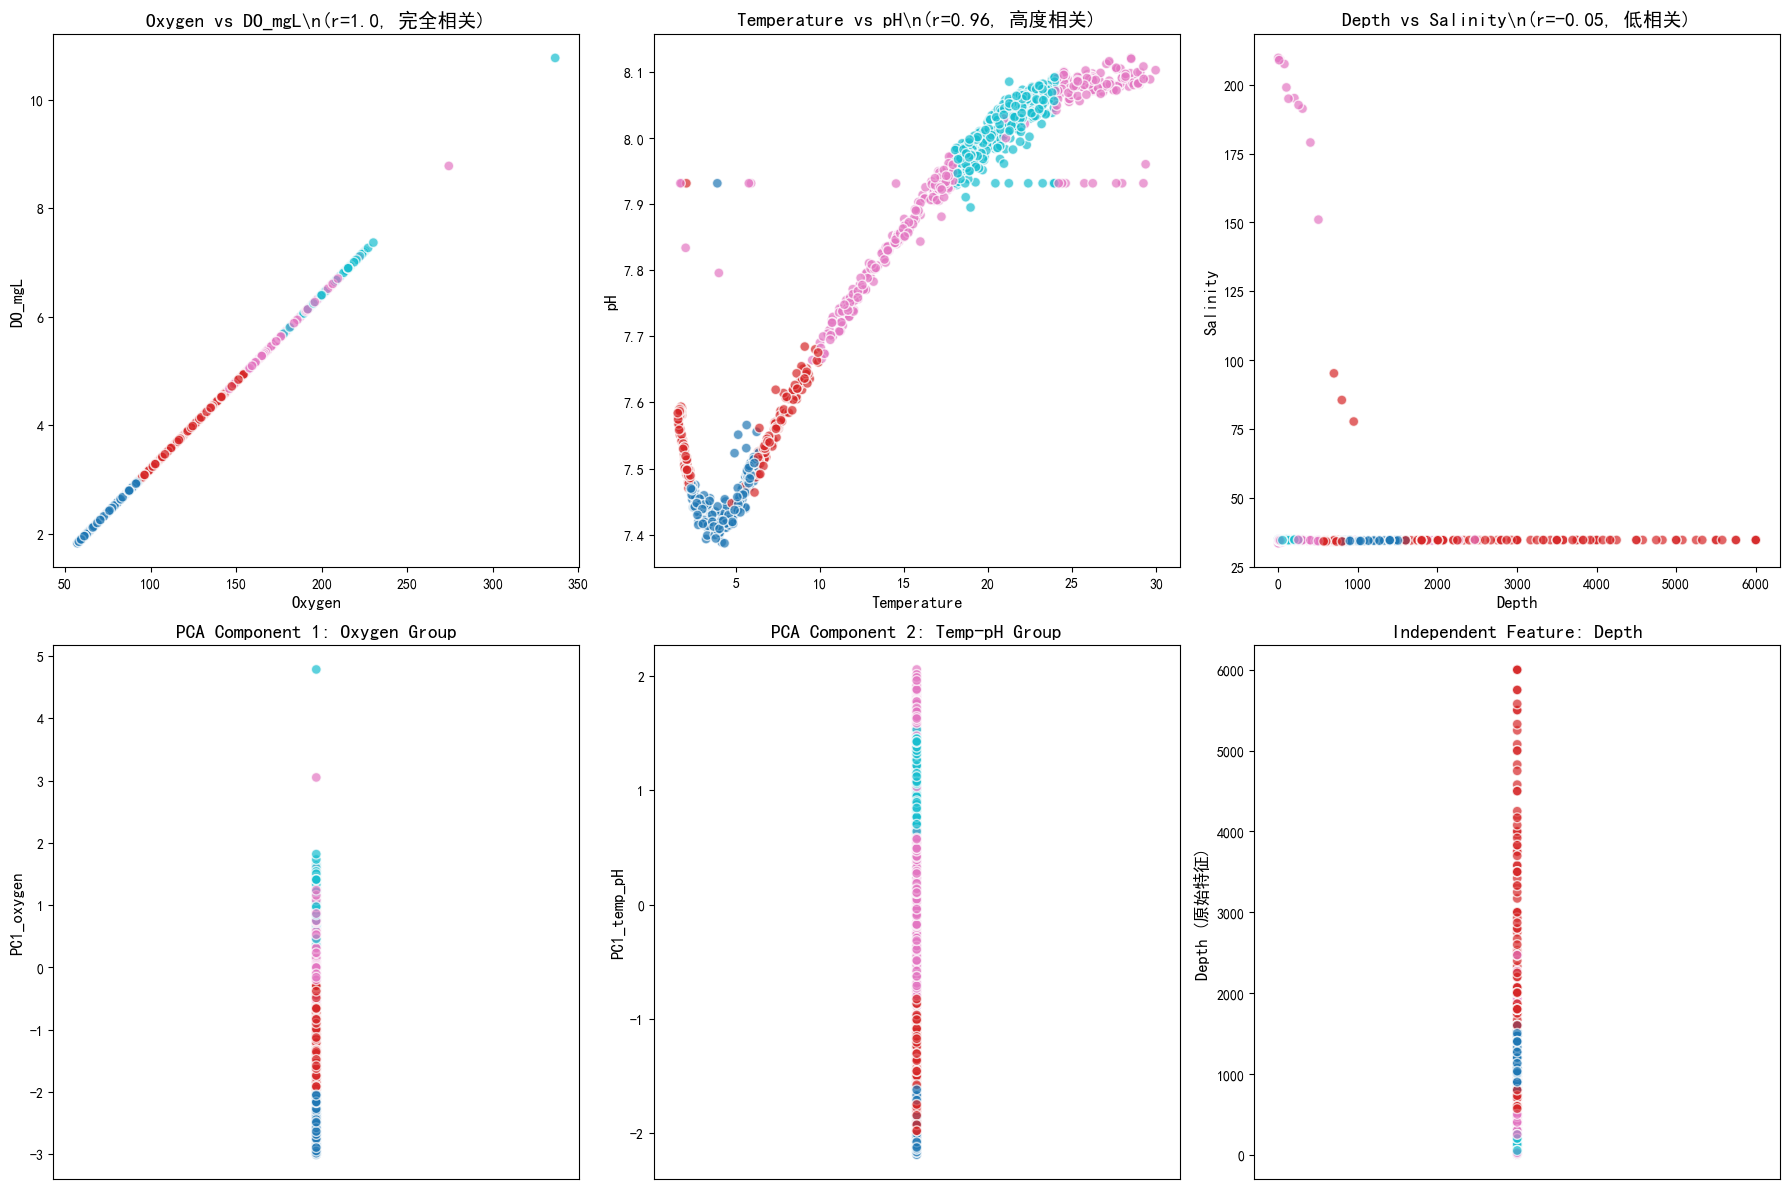


PCA特征与水质等级的相关性:
PC1_oxygen: Spearman r = 0.8555 (p=0.0000e+00) ***
PC1_temp_pH: Spearman r = 0.7632 (p=5.3432e-231) ***
Depth: Spearman r = -0.7518 (p=2.5173e-220) ***
Salinity: Spearman r = 0.5680 (p=3.9985e-104) ***

PCA后特征间的相关性矩阵:
             PC1_oxygen  PC1_temp_pH  Depth  Salinity
PC1_oxygen        1.000        0.925 -0.504     0.059
PC1_temp_pH       0.925        1.000 -0.695     0.054
Depth            -0.504       -0.695  1.000    -0.047
Salinity          0.059        0.054 -0.047     1.000

观察:
- PCA后的特征应该彼此独立性更强（相关性更低）
- 如果某些PCA特征之间仍有高相关性，可能需要重新考虑分组策略


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# 1. Oxygen vs DO_mgL (完全相关)
scatter1 = axes[0, 0].scatter(
    X_train['Oxygen'], 
    X_train['DO_mgL'], 
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolors='w'
)
axes[0, 0].set_xlabel('Oxygen', fontsize=12)
axes[0, 0].set_ylabel('DO_mgL', fontsize=12)
axes[0, 0].set_title('Oxygen vs DO_mgL\\n(r=1.0, 完全相关)', fontsize=14)

# 2. Temperature vs pH (高度相关)
scatter2 = axes[0, 1].scatter(
    X_train['Temperature'], 
    X_train['pH'], 
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolors='w'
)
axes[0, 1].set_xlabel('Temperature', fontsize=12)
axes[0, 1].set_ylabel('pH', fontsize=12)
axes[0, 1].set_title('Temperature vs pH\\n(r=0.96, 高度相关)', fontsize=14)

# 3. Depth vs Salinity (低相关)
scatter3 = axes[0, 2].scatter(
    X_train['Depth'], 
    X_train['Salinity'], 
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolors='w'
)
axes[0, 2].set_xlabel('Depth', fontsize=12)
axes[0, 2].set_ylabel('Salinity', fontsize=12)
axes[0, 2].set_title('Depth vs Salinity\\n(r=-0.05, 低相关)', fontsize=14)

# 4. PC1_oxygen分布
axes[1, 0].scatter(
    np.zeros(len(X_train_group1_pca)),
    X_train_group1_pca.flatten(),
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolors='w'
)
axes[1, 0].set_xlim(-0.5, 0.5)
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('PC1_oxygen', fontsize=12)
axes[1, 0].set_title('PCA Component 1: Oxygen Group', fontsize=14)
axes[1, 0].set_xticks([])

# 5. PC1_temp_pH分布
axes[1, 1].scatter(
    np.zeros(len(X_train_group2_pca)),
    X_train_group2_pca.flatten(),
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolors='w'
)
axes[1, 1].set_xlim(-0.5, 0.5)
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('PC1_temp_pH', fontsize=12)
axes[1, 1].set_title('PCA Component 2: Temp-pH Group', fontsize=14)
axes[1, 1].set_xticks([])

# 6. 独立特征示例 - Depth分布

axes[1, 2].scatter(
    np.zeros(len(X_train)),
    X_train['Depth'].values,
    c=y_train,
    cmap='tab10',
    alpha=0.7,
    s=50,
    edgecolors='w'
)
axes[1, 2].set_xlim(-0.5, 0.5)
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('Depth (原始特征)', fontsize=12)
axes[1, 2].set_title('Independent Feature: Depth', fontsize=14)
axes[1, 2].set_xticks([])

plt.tight_layout()
plt.savefig('PCA分组可视化.png', dpi=300, bbox_inches='tight')
plt.show()
# 检查PCA特征与目标的相关性\n",
from scipy.stats import spearmanr
print("\n" + "="*60)
print("PCA特征与水质等级的相关性:")
print("="*60)
for pc_feature in X_train_pca_all.columns:
    corr, p_value = spearmanr(X_train_pca_all[pc_feature], y_train)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{pc_feature}: Spearman r = {corr:.4f} (p={p_value:.4e}) {significance}")

print("\n" + "="*60)
print("PCA后特征间的相关性矩阵:")
print("="*60)
pca_corr = X_train_pca_all.corr()
print(pca_corr.round(3))

print("\n观察:")
print("- PCA后的特征应该彼此独立性更强（相关性更低）")
print("- 如果某些PCA特征之间仍有高相关性，可能需要重新考虑分组策略")

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                           classification_report, f1_score)

print("数据准备完成!")
print(f"训练集形状: {X_train_pca_all.shape}")
print(f"测试集形状: {X_test_pca_all.shape}")
print(f"类别数: {len(np.unique(y_train))}")

数据准备完成!
训练集形状: (1208, 4)
测试集形状: (302, 4)
类别数: 4


In [40]:
model = LogisticRegression(
    multi_class='multinomial',  # 使用softmax回归（多分类）
    solver='lbfgs',            # 适合中小型数据集
    max_iter=1000,             # 最大迭代次数
    random_state=42            # 随机种子，确保结果可重复
)

print("开始训练逻辑回归模型...")
model.fit(X_train_pca_all, y_train)
print("训练完成!")

# 查看模型是否收敛
print(f"模型是否收敛: {model.n_iter_} 次迭代")

开始训练逻辑回归模型...
训练完成!
模型是否收敛: [1000] 次迭代


c:\Users\slan\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\slan\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



模型参数分析
类别: [0 1 2 3]
系数矩阵形状: (4, 4)
截距项: [-0.00534084 -3.16834071 -0.60953682  3.78321837]

系数矩阵（每个特征对每个类别的贡献）:
         PC1_oxygen  PC1_temp_pH  Depth  Salinity
Class_0      -6.313       -2.117  0.004    -0.399
Class_1       0.790       -2.765  0.003     0.084
Class_2       1.145        4.435  0.004     0.172
Class_3       4.378        0.447 -0.011     0.142

系数解释（正值增加该类别的概率，负值减少该类别的概率）:

PC1_oxygen:
  对类别0: 降低概率 (系数: -6.313)
  对类别1: 增加概率 (系数: 0.790)
  对类别2: 增加概率 (系数: 1.145)
  对类别3: 增加概率 (系数: 4.378)

PC1_temp_pH:
  对类别0: 降低概率 (系数: -2.117)
  对类别1: 降低概率 (系数: -2.765)
  对类别2: 增加概率 (系数: 4.435)
  对类别3: 增加概率 (系数: 0.447)

Depth:

Salinity:
  对类别0: 降低概率 (系数: -0.399)
  对类别2: 增加概率 (系数: 0.172)
  对类别3: 增加概率 (系数: 0.142)


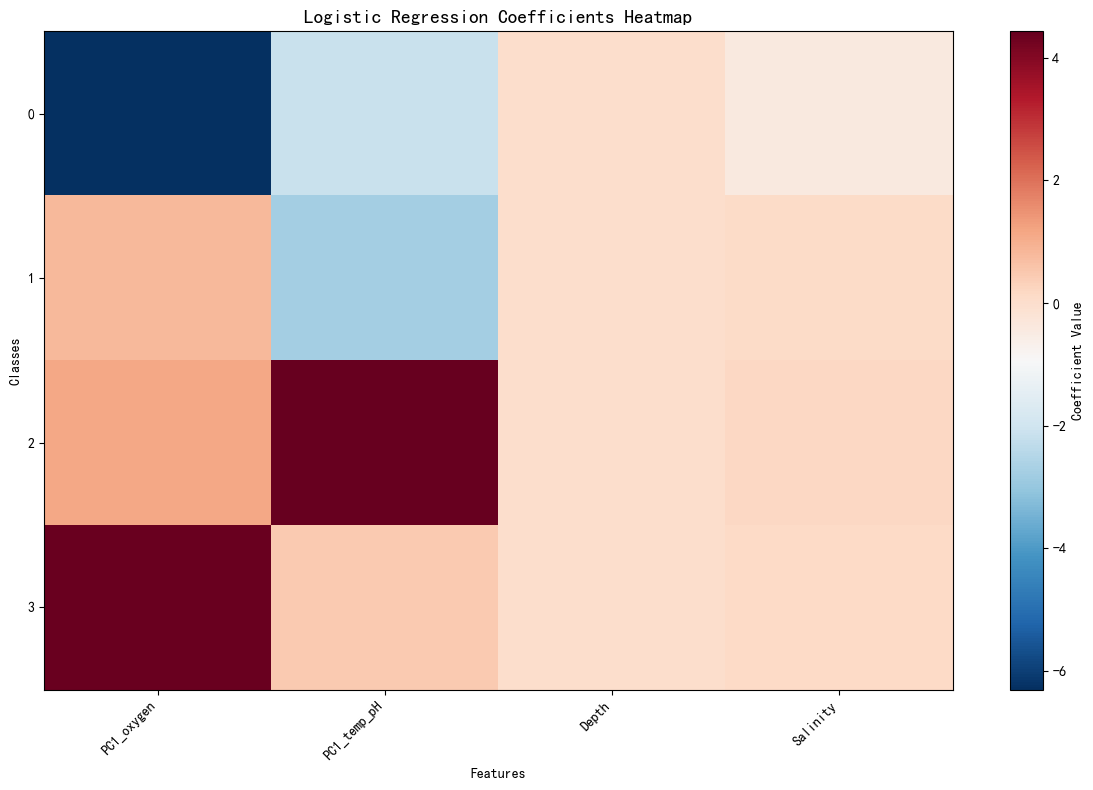


PCA主成分的物理解释

PC1_oxygen (溶解氧主成分):
  - 由 Oxygen 和 DO_mgL 组合而成
  - 这两个特征完全相关(r=1.0)
  - PC1_oxygen 代表水体的整体溶解氧水平
  - 高值表示高溶解氧含量

PC1_temp_pH (温度-pH主成分):
  - 由 Temperature 和 pH 组合而成
  - 这两个特征高度相关(r=0.96)
  - PC1_temp_pH 代表水体的温度-酸碱度综合状态
  - 通常温度和pH会同时升高或降低

独立特征:
  - Depth: 水深，直接影响光照、压力等环境因素
  - Salinity: 盐度，影响水的密度和生物适应性




In [41]:
# 查看模型参数
print("\n" + "="*60)
print("模型参数分析")
print("="*60)

print(f"类别: {model.classes_}")
print(f"系数矩阵形状: {model.coef_.shape}")  # (类别数, 特征数)
print(f"截距项: {model.intercept_}")

# 查看每个特征的系数 - 使用正确的特征名称
feature_names = list(X_train_pca_all.columns)  # ['PC1_oxygen', 'PC1_temp_pH', 'Depth', 'Salinity']
coef_df = pd.DataFrame(
    model.coef_,
    columns=feature_names,
    index=[f'Class_{cls}' for cls in model.classes_]
)

print("\n系数矩阵（每个特征对每个类别的贡献）:")
print(coef_df.round(3))

# 解释系数含义
print("\n系数解释（正值增加该类别的概率，负值减少该类别的概率）:")
for feature in feature_names:
    print(f"\n{feature}:")
    for i, cls in enumerate(model.classes_):
        coef_val = coef_df.loc[f'Class_{cls}', feature]
        if abs(coef_val) > 0.1:  # 只显示显著的影响
            direction = "增加" if coef_val > 0 else "降低"
            print(f"  对类别{cls}: {direction}概率 (系数: {coef_val:.3f})")

# 可视化系数热力图
plt.figure(figsize=(12, 8))
plt.imshow(model.coef_, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(label='Coefficient Value')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.title('Logistic Regression Coefficients Heatmap', fontsize=14)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(model.classes_)), model.classes_)
plt.tight_layout()
plt.savefig('逻辑回归系数热力图.png', dpi=300, bbox_inches='tight')
plt.show()

# 额外分析：PCA主成分的物理意义
print("\n" + "="*60)
print("PCA主成分的物理解释")
print("="*60)
print("\nPC1_oxygen (溶解氧主成分):")
print("  - 由 Oxygen 和 DO_mgL 组合而成")
print("  - 这两个特征完全相关(r=1.0)")
print("  - PC1_oxygen 代表水体的整体溶解氧水平")
print("  - 高值表示高溶解氧含量")
print("\nPC1_temp_pH (温度-pH主成分):")
print("  - 由 Temperature 和 pH 组合而成")
print("  - 这两个特征高度相关(r=0.96)")
print("  - PC1_temp_pH 代表水体的温度-酸碱度综合状态")
print("  - 通常温度和pH会同时升高或降低")
print("\n独立特征:")
print(f"  - Depth: 水深，直接影响光照、压力等环境因素")
print(f"  - Salinity: 盐度，影响水的密度和生物适应性")
print("\n")


模型性能评估
训练集准确率: 0.8088 (80.9%)
测试集准确率: 0.8146 (81.5%)
训练集加权F1: 0.8081
测试集加权F1: 0.8150

测试集分类报告:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.95      0.97        58
           2       0.72      0.73      0.73        98
           3       0.73      0.73      0.73        99

    accuracy                           0.81       302
   macro avg       0.85      0.85      0.85       302
weighted avg       0.82      0.81      0.81       302

混淆矩阵:
[[47  0  0  0]
 [ 2 55  1  0]
 [ 0  0 72 26]
 [ 0  0 27 72]]


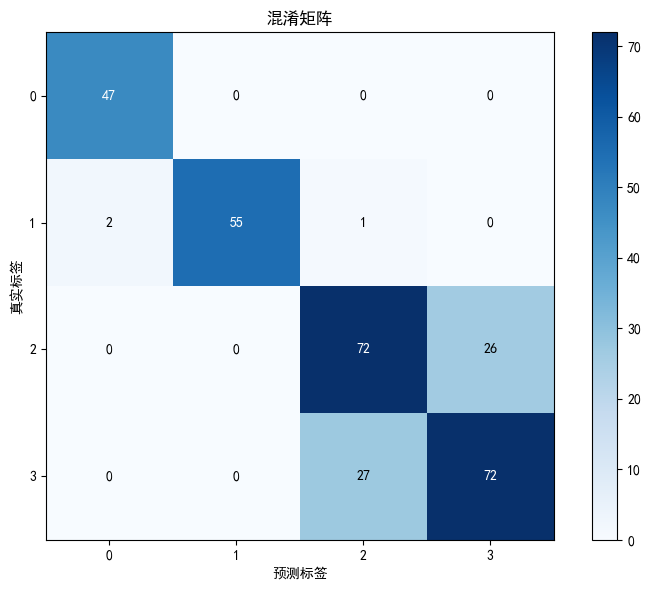

In [42]:
y_pred_train = model.predict(X_train_pca_all)
y_pred_test = model.predict(X_test_pca_all)

# 计算准确率
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("\n" + "="*60)
print("模型性能评估")
print("="*60)
print(f"训练集准确率: {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"测试集准确率: {test_acc:.4f} ({test_acc*100:.1f}%)")

# 计算F1分数
train_f1 = f1_score(y_train, y_pred_train, average='weighted')
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
print(f"训练集加权F1: {train_f1:.4f}")
print(f"测试集加权F1: {test_f1:.4f}")

# 详细分类报告
print("\n测试集分类报告:")
print(classification_report(y_test, y_pred_test))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_test)
print("混淆矩阵:")
print(cm)

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('混淆矩阵')
plt.colorbar()
tick_marks = np.arange(len(model.classes_))
plt.xticks(tick_marks, model.classes_)
plt.yticks(tick_marks, model.classes_)
plt.xlabel('预测标签')
plt.ylabel('真实标签')

# 在图中显示数字
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

In [43]:
# 使用网格搜索寻找最佳参数
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("模型调优（网格搜索）")
print("="*60)

# 定义参数网格
param_grid = [
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],  # 正则化强度的倒数，C越小正则化越强
        'penalty': ['l2'],  # 正则化类型
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'max_iter': [1000, 2000]
    },
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],  # L1正则化
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    }
]

# 创建逻辑回归模型
log_reg = LogisticRegression(
    multi_class='multinomial',
    random_state=42
)

# 创建网格搜索对象
grid_search = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,  # 5折交叉验证
    scoring='accuracy',
    n_jobs=-1,  # 使用所有CPU核心
    verbose=1
)

print("开始网格搜索...")
grid_search.fit(X_train_pca_all, y_train)

print(f"\n最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证准确率: {grid_search.best_score_:.4f}")

# 使用最佳模型
best_model = grid_search.best_estimator_

# 评估最佳模型
y_pred_best = best_model.predict(X_test_pca_all)
best_acc = accuracy_score(y_test, y_pred_best)

print(f"测试集准确率: {best_acc:.4f}")

# 与默认参数模型比较
print(f"\n模型比较:")
print(f"  默认参数模型准确率: {test_acc:.4f}")
print(f"  调优后模型准确率: {best_acc:.4f}")
print(f"  提升: {(best_acc - test_acc)/test_acc*100:.2f}%")


模型调优（网格搜索）
开始网格搜索...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

最佳参数: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'newton-cg'}
最佳交叉验证准确率: 0.8129
测试集准确率: 0.7980

模型比较:
  默认参数模型准确率: 0.8146
  调优后模型准确率: 0.7980
  提升: -2.03%


c:\Users\slan\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\slan\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\slan\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\slan\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_